# Data Challenge 8 — Introduction to Multiple Linear Regression (MLR)


**Format:** Instructor Guidance → You Do (Students) → We Share (Reflection)


**Goal:** Build an **MLR** model using **2–3 predictors** to predict one numeric target. Evaluate with a **train–test split** (MAE/RMSE), interpret **coefficients while holding others constant**, and compare against an **SLR baseline**.


> Dataset: **NYC Yellow Taxi — Dec 2023** (CSV). Keep code *simple*: light numeric coercion only for your chosen columns.

## Instructor Guidance

**Docs (quick links):**
- Train/Test Split — scikit‑learn: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- MAE / MSE / RMSE — scikit‑learn: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html
- OLS (fit/predict/residuals) — statsmodels: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html
- OLS Results (`resid`, `fittedvalues`, `summary`) — statsmodels: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html
- Q–Q plot — SciPy: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html


### Pseudocode Plan (for **MLR**)
1) **Load CSV** → preview columns/shape.
2) **Assign Y and Xs (2–3 predictors)** → pick numeric columns that matter; if needed, coerce **just** these to numeric and drop NAs.
3) **Add intercept** → `X = add_constant(X_matrix)`.
4) **Train–test split (80/20)** → `X_train, X_test, y_train, y_test = train_test_split(...)` (set `random_state`).
5) **Fit on TRAIN** → `model = OLS(y_train, X_train).fit()`.
6) **Predict on TEST** → `y_pred = model.predict(X_test)`.
7) **Evaluate on TEST** → compute **MAE** and **RMSE** using `y_test` & `y_pred`; speak in **units of Y**.
8) **Diagnostics on TRAIN** → use `model.resid` & `model.fittedvalues` for residuals vs fitted; Q–Q plot; check Durbin–Watson in `model.summary()`.
9) **Bias–variance read (optional)** → compare train vs test errors.
10) **Stakeholder one‑liner** → MAE/RMSE in units + brief reliability note. *(Optional)* Contrast with an **SLR baseline** using the strongest single predictor.

## You Do — Student Section
Work in pairs. Keep code simple and comment your choices.

### Step 0 — Setup & Imports

In [187]:
import pandas as pd, numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

### Step 1 — Load CSV & Preview
- Point to your **Dec 2023** taxi CSV.
- Print **shape** and **columns**.

**Hint: You may have to drop missing values and do a force coercion to make sure the variables stay numeric (other coding assignments may help)**

In [188]:
df = pd.read_csv("../data/2023_Yellow_Taxi_Trip_Data_20251015.csv")

/var/folders/3y/ldxff8k17wjcyzkq19xw1srm0000gn/T/ipykernel_30872/3679277489.py:1: DtypeWarning: Columns (4,10,13,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/2023_Yellow_Taxi_Trip_Data_20251015.csv")


In [189]:
df['total_fees'] = df['improvement_surcharge'] + df['congestion_surcharge'] + df['airport_fee'] +df['tolls_amount'] + df['mta_tax']

# Coerce fare, distance to numeric safely
num_cols = ['fare_amount', 'trip_distance','extra','tip_amount','total_fees']
for c in num_cols:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
)
    
# Clean data some by removing values less than 0 and dropping NAN values
df = df[(df['tip_amount'] >= 0) & (df['trip_distance'] > 0) & (df['total_fees'] >=0)]
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=num_cols)

In [190]:
# total rows before dropping any nan is 3310907
# after dropping nan rows = 3056649 and filtering for values greater than or equal to 0 dependent on feature

# picking values that are less than the 99.99% because there are some significantly high values

#first filter rows = 3056345
df = df[df['fare_amount'] <= df['fare_amount'].quantile(0.9999)]

#second filter rows = 3055734
df = df[df['trip_distance'] <= df['trip_distance'].quantile(0.9999)]

#last filter rows = 3055093
#increased the value of percentile as it was removing too many larger values if i did 0.9999
df = df[df['total_fees'] <= df['total_fees'].quantile(0.99999)]

# lost about 7.72% of our original data (something to keep in mind). most of which were significantly larger values or nan values.

In [191]:
print(df.shape)
display(df.info())

(3056008, 20)
<class 'pandas.core.frame.DataFrame'>
Index: 3056008 entries, 0 to 3310906
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           object 
 17  congestion_surcharge   float64
 18  airport_fee            float64
 19  total_fees             float64
dtypes: float64(12), int64(4), object(4)
memory usage: 489.6+ MB


None

<Axes: xlabel='trip_distance', ylabel='tip_amount'>

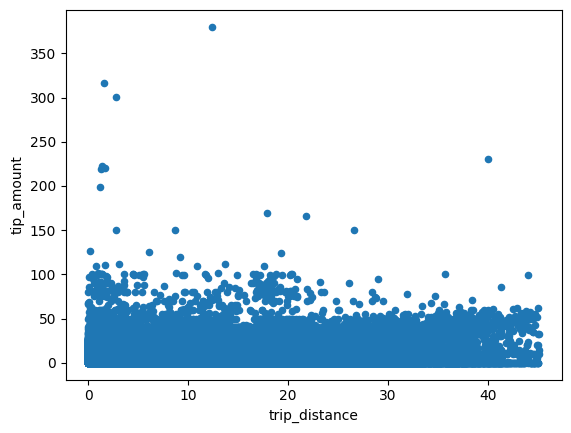

In [192]:
# not much of a slope between trip_distance and tip amount
df.plot(kind='scatter',x='trip_distance',y='tip_amount')

<Axes: xlabel='total_fees', ylabel='tip_amount'>

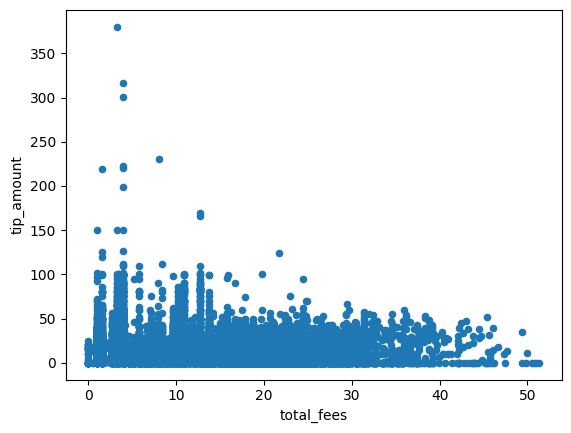

In [193]:
# also not much of a slope between total fees and tip amount.
# will be interesting to see mlr with these two
df.plot(kind='scatter',x='total_fees',y='tip_amount')

### Step 2 —  Pick Target **Y** and Predictors **Xs** (choose 2–3 numeric)

- **Avoid** using an X that directly defines Y (e.g., `total_amount` when Y = `fare_amount`).
- Coerce **only these columns** to numeric; drop NA rows.

In [194]:
y = df['tip_amount']
X_sm = df[['trip_distance', 'total_fees']]

### Step 3 —  Design Matrix (add intercept) & Train–Test Split (80/20)

- Add intercept with `sm.add_constant`.
- Use a **random_state** for reproducibility.
- (Optional) Discuss when a **time‑aware** split is better.

In [195]:
X_sm = sm.add_constant(X_sm)

np.random.seed(10)
X_train, X_test, y_train, y_test = train_test_split(X_sm, y, test_size=0.2, random_state=10)

print(f"X Training data shape: {X_train.shape}")
print(f"X Testing data shape:  {X_test.shape}")
print(f"Y Training data shape: {y_train.shape}")
print(f"Y Testing data shape:  {y_test.shape}")

X Training data shape: (2444806, 3)
X Testing data shape:  (611202, 3)
Y Training data shape: (2444806,)
Y Testing data shape:  (611202,)


### Step 4 — Fit MLR on TRAIN & Interpret Coefficients (holding others constant)

- Print the **coefficient table**.
- Write **one unit‑based sentence per coefficient** using “**holding others constant**.”

In [196]:
model = sm.OLS(y_train, X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             tip_amount   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.353
Method:                 Least Squares   F-statistic:                 6.670e+05
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:09:31   Log-Likelihood:            -6.3514e+06
No. Observations:             2444806   AIC:                         1.270e+07
Df Residuals:                 2444803   BIC:                         1.270e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.7798      0.005    164.179      0.000       0.770       0.789
trip_distance     0.4158      0.001    650.656      0.000       0.415       0.417
total_fees        0.3261      0.001    276.290      0.000       0.324       0.328
==============================================================================
Omnibus:                  2050052.309   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):       2747669656.709
Skew:                           2.743   Prob(JB):                         0.00
Kurtosis:                     167.143   Cond. No.                         16.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

When all predictors are 0, our tip_amount is 0.77 cents.

While holding total_fees constant, as your trip_distance increase in mileage, your tip amount also increases by 41 cents per mile.

While holding trip_distance constant, as your total_fees increase by one unit, your tip amount also increases by 32 cents.



*Template (edit to your variables & units):*
- **β_intercept (const):** Baseline Y when all predictors are 0 (may be a math anchor).
- **β_X1:** Holding other predictors constant, +1 unit in **X1** is associated with **+β_X1** units in **Y**.
- **β_X2:** Holding other predictors constant, +1 unit in **X2** is associated with **+β_X2** units in **Y**.
- *(If 3rd predictor)* **β_X3:** …
- **Significance:** Note **p‑values** and **95% CIs** (from statsmodels summary) if relevant.

### Step 5 — Evaluate on **Unseen Test Data** (MAE/RMSE in units of Y)
Compute MAE and RMSE and write a one‑sentence **stakeholder** readout.

In [197]:
# --- Evaluate the model on the unseen testing data ---
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"\nMean Absolute Error (MAE) on Test Data: {mae:.2f}")
print(f"Root Mean Squared Error (RMSE) on Test Data: {rmse:.2f}")
print(f"\nInterpretation: Our model's predictions on new data are off by an average of ${mae:,.2f}.")

print(f"\nWith a tip amount median of $2.94, within the context of tip amount, it is a large margin of error.")



Mean Absolute Error (MAE) on Test Data: 2.10
Root Mean Squared Error (RMSE) on Test Data: 3.29

Interpretation: Our model's predictions on new data are off by an average of $2.10.

With a tip amount median of $2.94, within the context of tip amount, it is a large margin of error.


### Step 6 — (Optional) Compare to an SLR Baseline
- Fit **SLR** using your strongest single predictor (e.g., `trip_distance`).
- Compare **MAE/RMSE** to your **MLR**; explain why MLR helped (or didn’t).

In [198]:
np.random.seed(15)
Xslr = sm.add_constant(df['trip_distance'])
yslr = df['tip_amount']

X_trainslr, X_testslr, y_trainslr, y_testslr = train_test_split(Xslr, yslr, test_size=0.2, random_state=15)

print(f"X Training data shape: {X_trainslr.shape}")
print(f"X Testing data shape:  {X_testslr.shape}")
print(f"Y Training data shape: {y_trainslr.shape}")
print(f"Y Testing data shape:  {y_testslr.shape}")

modelslr = sm.OLS(y_trainslr,X_trainslr).fit()
display(modelslr.summary())

X Training data shape: (2444806, 2)
X Testing data shape:  (611202, 2)
Y Training data shape: (2444806,)
Y Testing data shape:  (611202,)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             tip_amount   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                 1.206e+06
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:10:08   Log-Likelihood:            -6.4005e+06
No. Observations:             2444806   AIC:                         1.280e+07
Df Residuals:                 2444804   BIC:                         1.280e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.8781      0.003    704.144      0.000       1.873       1.883
trip_distance     0.5327      0.000   1098.247      0.000       0.532       0.534
==============================================================================
Omnibus:                  2259145.394   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):       3877847365.750
Skew:                           3.255   Prob(JB):                         0.00
Kurtosis:                     198.001   Cond. No.                         7.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [185]:
predictionsslr = modelslr.predict(X_testslr)

maeslr = mean_absolute_error(y_testslr, predictionsslr)
rmseslr = np.sqrt(mean_squared_error(y_testslr, predictionsslr))

print(f"\nMean Absolute Error (MAE) on Test Data: {mae:.2f}")
print(f"Root Mean Squared Error (RMSE) on Test Data: {rmse:.2f}")
print(f"\nInterpretation: Our model's predictions on new data are off by an average of ${mae:,.2f}.")


Mean Absolute Error (MAE) on Test Data: 2.12
Root Mean Squared Error (RMSE) on Test Data: 3.27

Interpretation: Our model's predictions on new data are off by an average of $2.12.


### Step 7 — Quick Diagnostics (Train Residuals)
- **Residuals vs Fitted:** random cloud ≈ good; cones/funnels suggest non‑constant variance.
- **Q–Q plot:** points roughly along diagonal (normality for inference).
- **Durbin–Watson:** printed in `model.summary()` (~2 suggests independence).

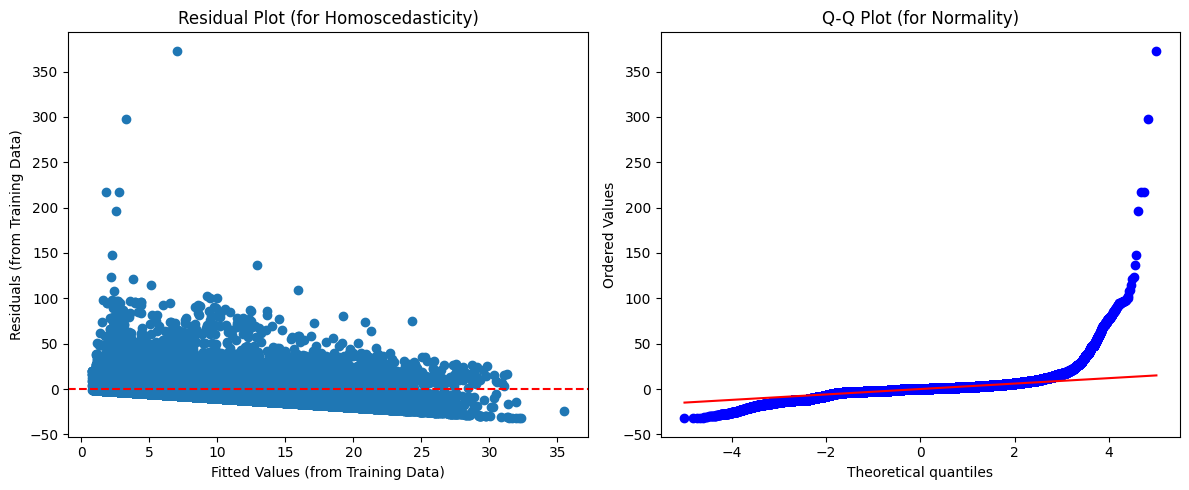

                            OLS Regression Results                            
Dep. Variable:             tip_amount   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.353
Method:                 Least Squares   F-statistic:                 6.670e+05
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:11:32   Log-Likelihood:            -6.3514e+06
No. Observations:             2444806   AIC:                         1.270e+07
Df Residuals:                 2444803   BIC:                         1.270e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.7798      0.005    164.179

In [199]:
# --- Check assumptions using the training data model ---
# Residuals from the model trained on X_train, y_train
train_residuals = model.resid 

# 1. Plot for Homoscedasticity
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(model.fittedvalues, train_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (for Homoscedasticity)')
plt.xlabel('Fitted Values (from Training Data)')
plt.ylabel('Residuals (from Training Data)')

# 2. Q-Q Plot for Normality
plt.subplot(1, 2, 2)
stats.probplot(train_residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot (for Normality)')

plt.tight_layout()
plt.show()

# 3. Durbin-Watson statistic is in the summary output below
print(model.summary())

## We Share — Reflection & Wrap‑Up
Write **2 short paragraphs** and be specific:


1) **Which model would you trust today—MLR or SLR—and why?**
Use **test MAE/RMSE (units)**, coefficient interpretations (holding others constant), and any residual/correlation observations.

I would trust the MLR more than the SLR as our MLR produces more precise and specificity to linear relationships. For example, although it was a small difference, being able to hold 'trip_distance' and 'total_fees' constant in my linear regression instead of just 'trip_distance' improved my R squared by .02. This would mean that our inclusion of 'total_fares' helped the percentage of predictability towards our dependent variable, 'tip_amount'.

2) **What’s next to improve reliability?**
Options: add a more relevant predictor, use a **time‑aware split**, segment by ride type (airport vs. city), or prepare for **VIF/regularization** to handle collinearity.

Adding a new feature with a more relevant predictor of tip amount would allow for a more accurate prediction. For example, a feature that included the taxi driver's rating could be beneficial to promote taxi driver good behavior. In theory, if we were able to see a strong positive relationship between the average driver rating and tip amount then it would be an incentive to provide good customer experiences.